# Global Tech Startups 2026 - Exploratory Data Analysis

An EDA of 25,000 global tech startups (founded 2012–2025) examining how funding, valuation, burn rate, runway, geography, investor tier, and AI adoption relate to startup outcomes - and ultimately, which factors actually predict survival.

**Dataset:** `global_tech_startups_2026.csv` - 25,000 rows, 17 columns

## Questions Covered

1. How do funding, valuation, and burn rate scale across funding stages - is the jump gradual, or does one stage accelerate sharply?
2. Does Investor Tier reliably predict outcome, or do some Tier 3 (Angel/Seed)-backed startups outperform Tier 1-backed ones?
3. At what stage does a startup actually become "safe" on runway, and where's the riskiest transition?
4. Is there a runway threshold below which shutdown risk spikes sharply, or does risk rise gradually?
5. Does higher startup count per country mean higher average valuation, or are some countries producing quantity without quality?
6. Are certain domains geographically concentrated, and does that concentration correlate with survival odds?
7. Generative AI is the largest domain by far - does it also have the best survival rate, or is it just the most crowded?
8. Web3/Crypto stands out on failure metrics - what does its shutdown and layoff pattern actually look like?
9. Does "High" AI adoption translate into better valuation, longer runway, or fewer shutdowns?
10. Is AI adoption spread evenly across domains, or is it a byproduct of the business a company is in?
11. If AI adoption has little relationship with outcomes, what does that say about the market's "AI-native startup" narrative?
12. Which single metric should an investor watch most closely before writing a check - and why?

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df=pd.read_csv(r"C:\Users\OM THAKUR\Downloads\global_tech_startups_2026.csv",header=0)

In [4]:
df.head(5)


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [5]:
df_model = df.drop(columns=['Current_Headcount_2026'])

### Dropped Current_Headcount_2026 -
it's a perfect linear combination of Peak_Headcount_2023 and Layoffs_2024_2025 (Current = Peak - Layoffs, holds exactly for all 25,000 rows). Keeping it would add multicollinearity without adding new information.

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company_ID                  25000 non-null  object 
 1   Domain                      25000 non-null  object 
 2   Founding_Year               25000 non-null  int64  
 3   Country                     25000 non-null  object 
 4   City                        25000 non-null  object 
 5   Funding_Stage               25000 non-null  object 
 6   Total_Funding_USD_Millions  25000 non-null  float64
 7   Valuation_USD_Millions      25000 non-null  float64
 8   Revenue_ARR_Millions        25000 non-null  float64
 9   Monthly_Burn_Rate_Millions  25000 non-null  float64
 10  Runway_Months_2024          25000 non-null  float64
 11  Peak_Headcount_2023         25000 non-null  int64  
 12  Layoffs_2024_2025           25000 non-null  int64  
 13  Current_Headcount_2026      250

In [7]:
df.describe()

,Founding_Year,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,2018.917400,59.631098,464.100121,33.300890,3.168847,12.189032,211.739920,31.563320,180.176600
std,2.811963,208.725699,1777.909318,139.243809,10.877553,10.099990,693.946443,175.987811,606.174385
min,2012.000000,0.000000,1.030000,0.050000,0.060000,0.000000,5.000000,0.000000,0.000000
25%,2017.000000,2.050000,28.997500,1.800000,0.430000,3.900000,30.000000,0.000000,22.000000
50%,2019.000000,8.465000,71.775000,4.825000,0.720000,10.600000,48.000000,0.000000,42.000000
75%,2021.000000,36.100000,267.795000,17.972500,2.240000,17.500000,154.000000,16.000000,119.000000
max,2025.000000,7867.390000,91692.420000,9021.530000,515.760000,89.600000,30086.000000,10280.000000,25657.000000


Financial variables such as funding, valuation, revenue and headcount are strongly right-skewed, with a small number of very large startups creating extreme upper values


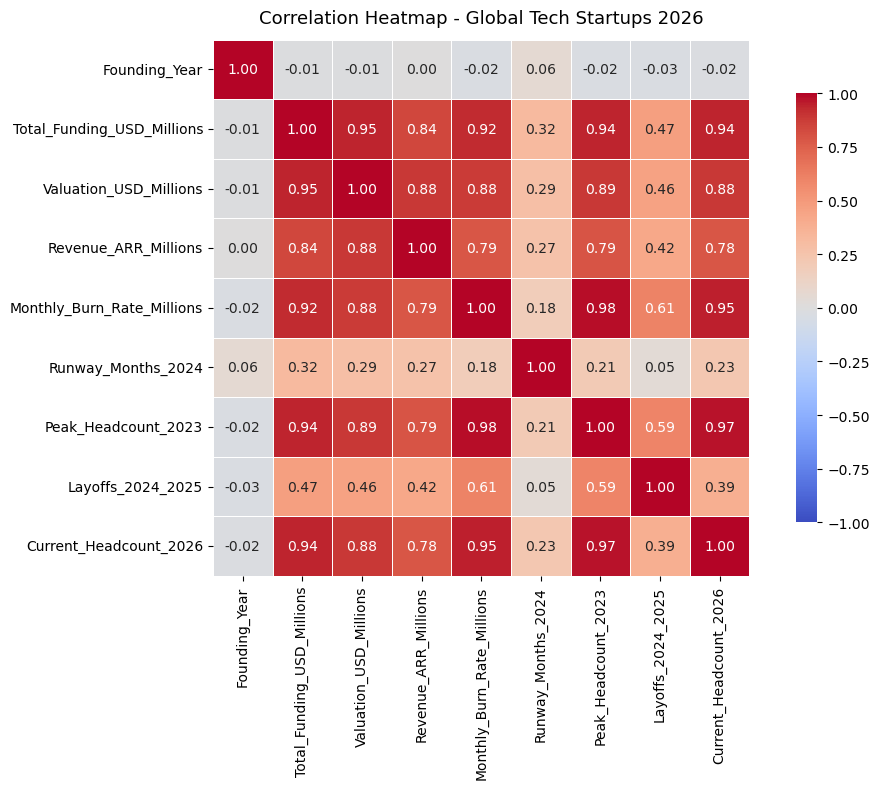

In [8]:
num_cols = ['Founding_Year', 'Total_Funding_USD_Millions', 'Valuation_USD_Millions',
            'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions', 'Runway_Months_2024',
            'Peak_Headcount_2023', 'Layoffs_2024_2025', 'Current_Headcount_2026']
corr = df[num_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap - Global Tech Startups 2026", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

The correlation heatmap reveals that startup scale metrics move together as a tight cluster. Monthly_Burn_Rate_Millions and Peak_Headcount_2023 are the most correlated pair in the dataset (r = 0.98).  

Runway_Months_2024 behaves differently its strongest correlation is with Total_Funding_USD_Millions at only r = 0.32, and it's nearly uncorrelated with Layoffs_2024_2025 (r = 0.05). This suggests runway is driven more by a company's burn discipline than by raw funding size or headcount a well-funded company can still have a short runway if it's burning fast.

Founding_Year stands apart from everything, with correlations near zero (−0.03 to 0.06) against every other numeric column. Company age has essentially no linear relationship with funding, valuation, size, or burn , older startups aren't systematically bigger or better-funded than younger ones in this dataset.

Worth noting: Peak Headcount and Current Headcount are very strongly related because current employees start from the peak employees. But layoffs change the final number for each company. Therefore, the relationship is very strong (0.97), but not perfectly linear (1.00).

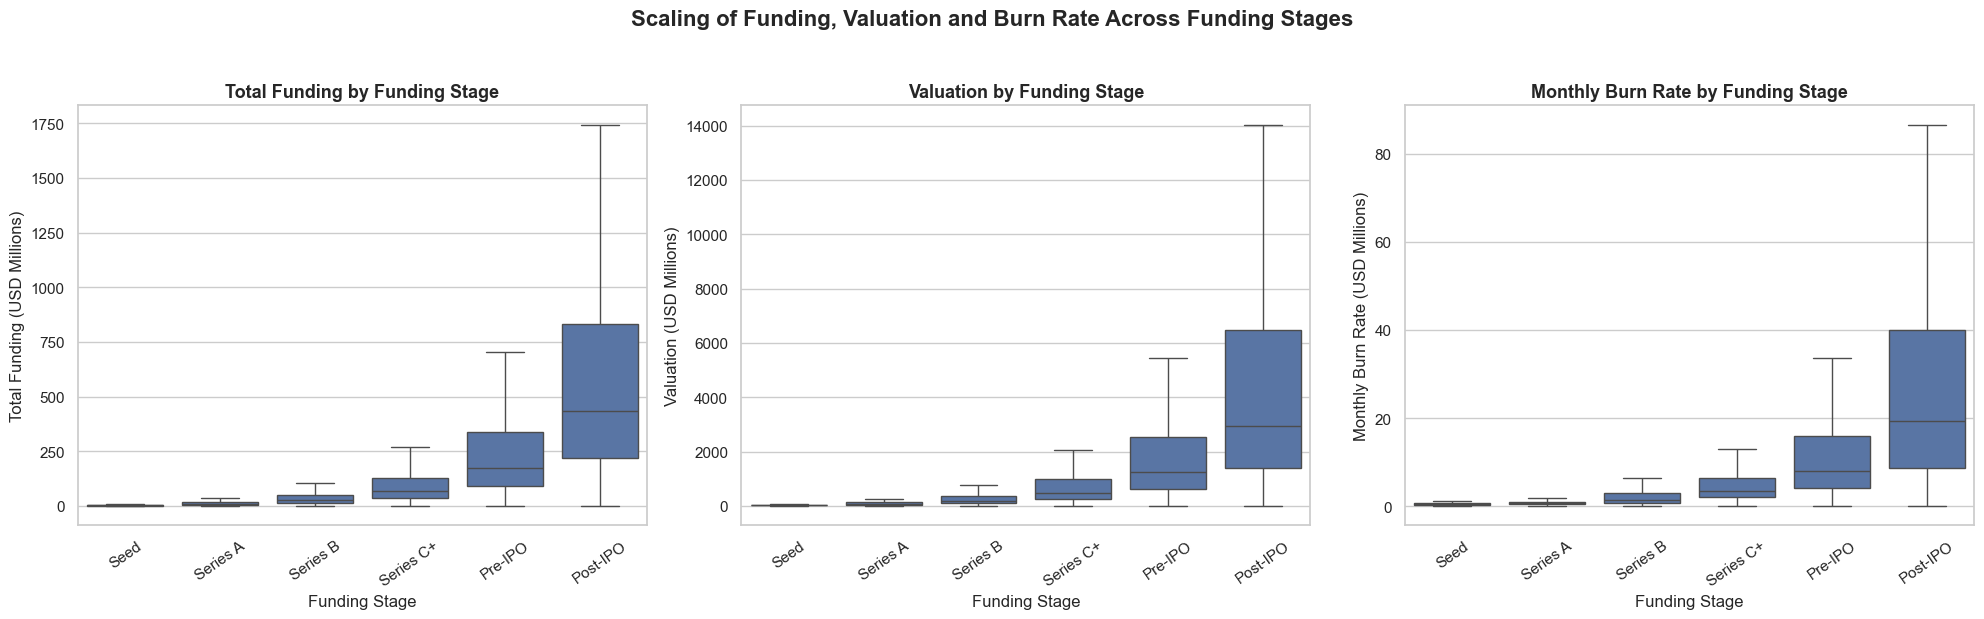

In [9]:
#Q1. How do funding,valuationand burn rate scale across Funding_Stage is the jump gradual or is there one stage where things suddenly accelerate?
# Keep funding stages in logical order
stage_order = ["Seed","Series A","Series B","Series C+","Pre-IPO","Post-IPO"]
# Set plotting style
sns.set_theme(style="whitegrid", font_scale=1.0)
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# 1. Total Funding
sns.boxplot(data=df,x="Funding_Stage",y="Total_Funding_USD_Millions",order=stage_order,ax=axes[0],showfliers=False)
axes[0].set_title("Total Funding by Funding Stage", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Funding Stage")
axes[0].set_ylabel("Total Funding (USD Millions)")
axes[0].tick_params(axis="x", rotation=35)

# 2. Valuation
sns.boxplot(data=df,x="Funding_Stage",y="Valuation_USD_Millions",order=stage_order,ax=axes[1],showfliers=False)
axes[1].set_title("Valuation by Funding Stage", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Funding Stage")
axes[1].set_ylabel("Valuation (USD Millions)")
axes[1].tick_params(axis="x", rotation=35)

# 3. Monthly Burn Rate
sns.boxplot(data=df,x="Funding_Stage",y="Monthly_Burn_Rate_Millions",order=stage_order,ax=axes[2],showfliers=False)
axes[2].set_title("Monthly Burn Rate by Funding Stage", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Funding Stage")
axes[2].set_ylabel("Monthly Burn Rate (USD Millions)")
axes[2].tick_params(axis="x", rotation=35)

# Overall title
plt.suptitle("Scaling of Funding, Valuation and Burn Rate Across Funding Stages",fontsize=16,fontweight="bold",y=1.03)
plt.tight_layout()
plt.show()

### Insight:
The three box plots demonstrate a strong scaling relationship between funding stage and financial scale. Funding, valuation and monthly burn rate all increase steadily from Seed to Post-IPO, but the rate of increase becomes substantially stronger at the later stages. The most noticeable acceleration occurs around Pre-IPO and Post-IPO, where both the median and spread of the values rise sharply. This suggests that advanced-stage startups operate on a fundamentally larger financial scale than early-stage startups.  

#### Important:  
The increasing height of the boxes does not mean every company at that stage has a high value. It means the distribution is becoming wider. For example, Post-IPO companies have a much greater range of funding, valuation and burn rate than Seed companies.  
Also, this dataset contains 8,859 Seed companies but only 720 Post-IPO companies, so the later-stage distributions are based on fewer observations. 

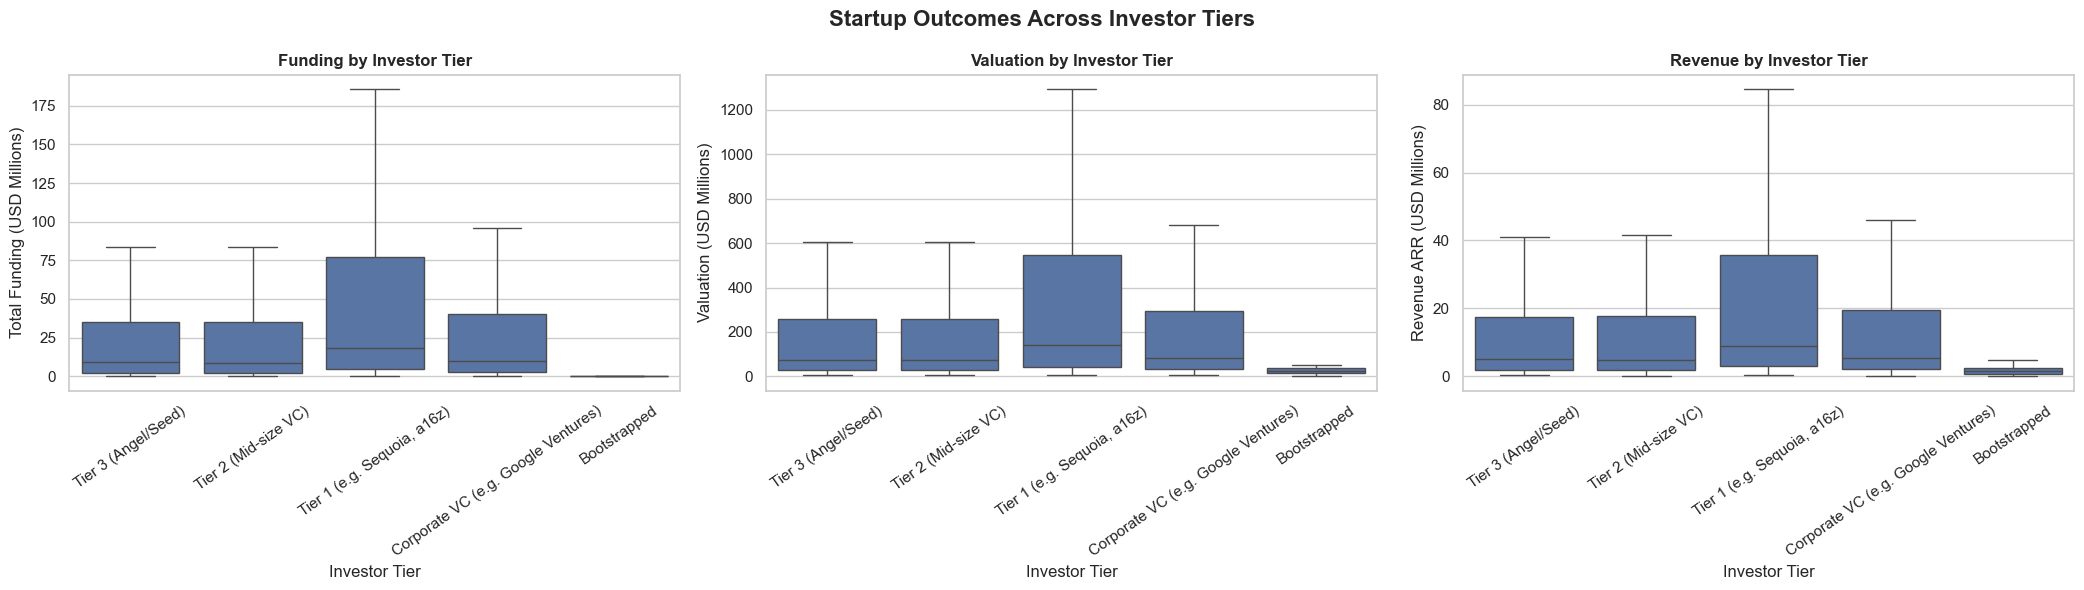

In [10]:
#Q2. Does Investor_Tier reliably associated with outcome, or are there Tier 3 (Angel/Seed)-backed startups quietly outperforming Tier 1-backed ones?
# Logical investor-tier order
tier_order = ["Tier 3 (Angel/Seed)","Tier 2 (Mid-size VC)","Tier 1 (e.g. Sequoia, a16z)","Corporate VC (e.g. Google Ventures)","Bootstrapped"]
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
# Funding
sns.boxplot(data=df,x="Investor_Tier",y="Total_Funding_USD_Millions",order=tier_order,showfliers=False,ax=axes[0])
axes[0].set_title("Funding by Investor Tier", fontweight="bold")
axes[0].set_xlabel("Investor Tier")
axes[0].set_ylabel("Total Funding (USD Millions)")
axes[0].tick_params(axis="x", rotation=35)

# Valuation
sns.boxplot(data=df,x="Investor_Tier",y="Valuation_USD_Millions",order=tier_order,showfliers=False,ax=axes[1])
axes[1].set_title("Valuation by Investor Tier", fontweight="bold")
axes[1].set_xlabel("Investor Tier")
axes[1].set_ylabel("Valuation (USD Millions)")
axes[1].tick_params(axis="x", rotation=35)

# Revenue
sns.boxplot(data=df,x="Investor_Tier",y="Revenue_ARR_Millions",order=tier_order,showfliers=False,ax=axes[2])
axes[2].set_title("Revenue by Investor Tier", fontweight="bold")
axes[2].set_xlabel("Investor Tier")
axes[2].set_ylabel("Revenue ARR (USD Millions)")
axes[2].tick_params(axis="x", rotation=35)

plt.suptitle("Startup Outcomes Across Investor Tiers",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

### Insight:
Investor Tier appears to be associated with startup performance, but it is not a guaranteed predictor of success. Tier 1-backed startups generally perform better, while the overlap with Tier 3 shows that some startups can outperform despite having lower-tier investors.

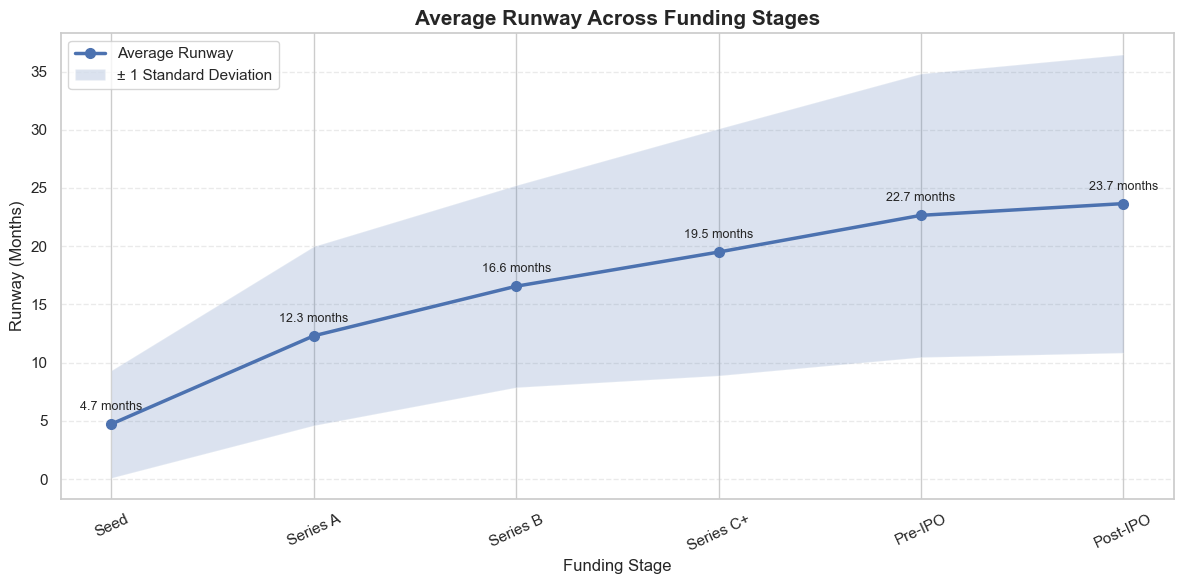

In [11]:
#Q3. Average runway climbs from ~4.7 months at Seed to ~23.7 months at Post-IPO -at what stage does a startup actually
#become "safe," and where's the riskiest transition?
stage_order = ["Seed","Series A","Series B","Series C+","Pre-IPO","Post-IPO"]
# Calculate mean and standard deviation of runway
runway_stats = (df.groupby("Funding_Stage")["Runway_Months_2024"].agg(["mean", "std"]).reindex(stage_order))
# Create line chart
plt.figure(figsize=(12, 6))
plt.plot(stage_order,runway_stats["mean"],marker="o",linewidth=2.5,markersize=7,label="Average Runway")
# Standard deviation shading
plt.fill_between(stage_order,runway_stats["mean"] - runway_stats["std"],runway_stats["mean"] + runway_stats["std"],alpha=0.2,
                 label="± 1 Standard Deviation")

# Add values above points
for stage, mean in zip(stage_order, runway_stats["mean"]):plt.annotate(f"{mean:.1f} months",(stage, mean),textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9
    )

plt.title(
    "Average Runway Across Funding Stages",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Funding Stage")
plt.ylabel("Runway (Months)")
plt.xticks(rotation=25)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

### Insight
The average runway increases strongly from 4.7 months at Seed to 23.7 months at Post-IPO, showing that startups become financially more resilient as they progress through funding stages.  
The risk transition is Seed → Series A, where average runway jumps from 4.7 to 12.3 months. Seed companies have the lowest runway and a relatively high standard deviation, indicating greater financial uncertainty.  
There is no single stage where a startup becomes completely safe. However, Series C+ and later stages appear considerably more financially stable, with average runway around 19.5–23.7 months.  
The shaded area represents ±1 standard deviation, so the wider the shaded region, the greater the variation in runway among companies at that stage.

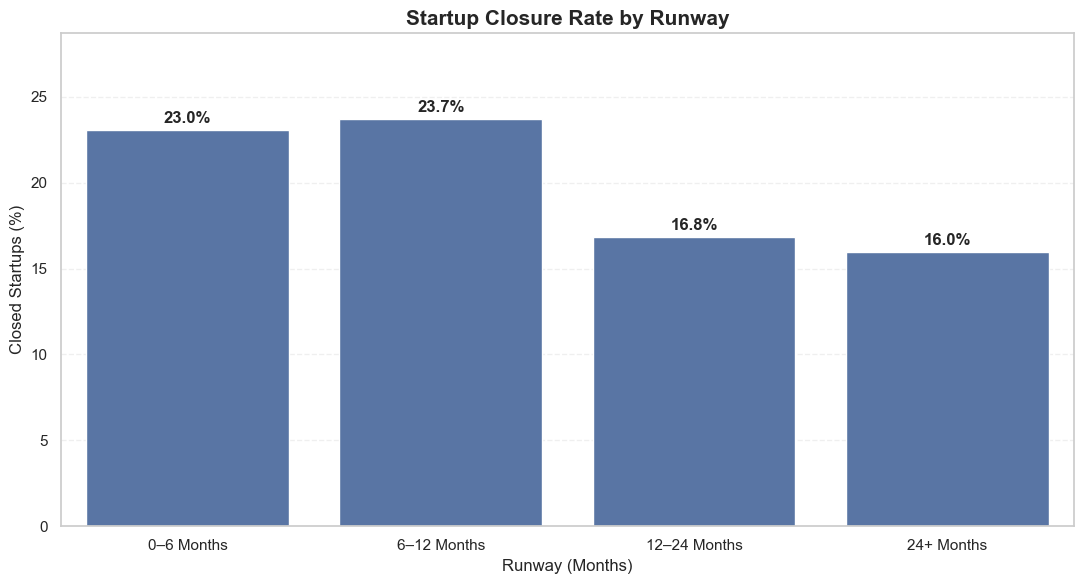

In [12]:
#Q4. Is there a runway threshold below which shutdown risk increases sharply?

# Create runway buckets
bins = [-0.001, 6, 12, 24, float("inf")]
labels = ["0–6 Months", "6–12 Months", "12–24 Months", "24+ Months"]

df["Runway_Bin"] = pd.cut(
    df["Runway_Months_2024"],
    bins=bins,
    labels=labels
)

# Calculate percentage of Closed startups in each runway bucket
closed_rate = (
    df.groupby("Runway_Bin", observed=False)["Acquisition_Status"]
      .apply(lambda x: (x == "Closed").mean() * 100)
)

# Plot
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=closed_rate.index,
    y=closed_rate.values
)

# Add percentage labels
for i, value in enumerate(closed_rate.values):
    ax.text(
        i,
        value + 0.4,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Startup Closure Rate by Runway",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Runway (Months)")
plt.ylabel("Closed Startups (%)")
plt.ylim(0, max(closed_rate.values) + 5)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Insight:
This suggests that shutdown risk does not increase continuously as runway decreases. Instead, the strongest risk appears when runway is below about 12 months, after which the closure rate drops noticeably. Therefore, 12 months can be viewed as an important risk threshold in this dataset, although it should not be interpreted as a guaranteed safe level.  

### Why does this happen?  
Startups with limited runway have less time to raise additional funding, improve revenue, or reduce costs. Once runway reaches 12+ months, companies generally have a larger financial buffer, which can reduce the likelihood of closure.  

### Important:   
this graph measures closure, not layoffs. So it supports conclusions about shutdown risk, but not whether layoffs “spike” at the same threshold.

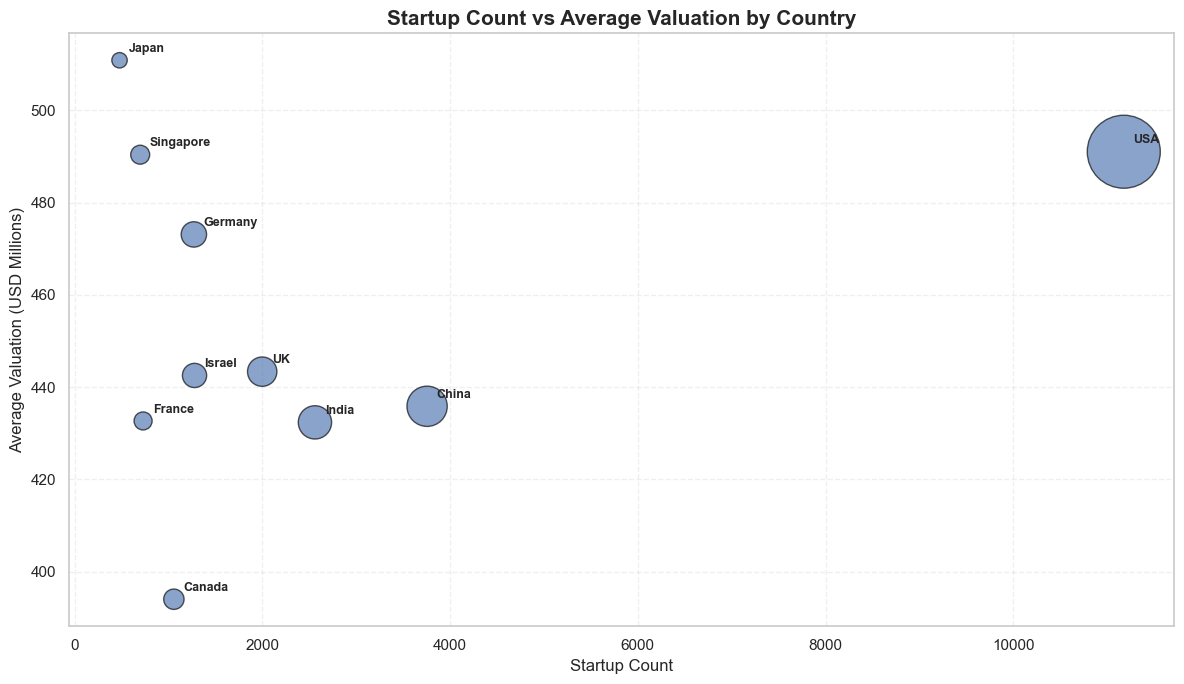

In [13]:
#Q5. The US, China, and India dominate by volume - but does higher startup count per country also mean higher average valuation, 
#or are some countries producing quantity without quality?
# Aggregate country-level metrics
country_stats = (df.groupby("Country").agg(Startup_Count=("Company_ID", "count"),Avg_Valuation=("Valuation_USD_Millions", "mean"),
Total_Funding=("Total_Funding_USD_Millions", "sum")).reset_index())
# Create bubble chart
plt.figure(figsize=(12, 7))
plt.scatter(country_stats["Startup_Count"],country_stats["Avg_Valuation"],s=country_stats["Total_Funding"] / 250,alpha=0.65,edgecolor="black")
# Add country labels
for _, row in country_stats.iterrows():plt.annotate(row["Country"],(row["Startup_Count"], row["Avg_Valuation"]),xytext=(7, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Startup Count vs Average Valuation by Country",fontsize=15,fontweight="bold")
plt.xlabel("Startup Count")
plt.ylabel("Average Valuation (USD Millions)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight:
The graph shows that startup count does not directly translate into higher average valuation. The USA has by far the largest number of startups (11,178) and also a high average valuation of about  $491M,but countries with much smaller startup counts can achieve similar or even higher average valuations. For example, Japan has only 478 startups but the highest average valuation at about Dollars 511M. Singapore also has a relatively small startup count but an average valuation of about Dollars 490M.

This means that high startup volume does not automatically mean higher quality. The US combines both scale and strong average valuation, while countries such as Japan and Singapore demonstrate that a smaller startup ecosystem can still produce highly valued companies.

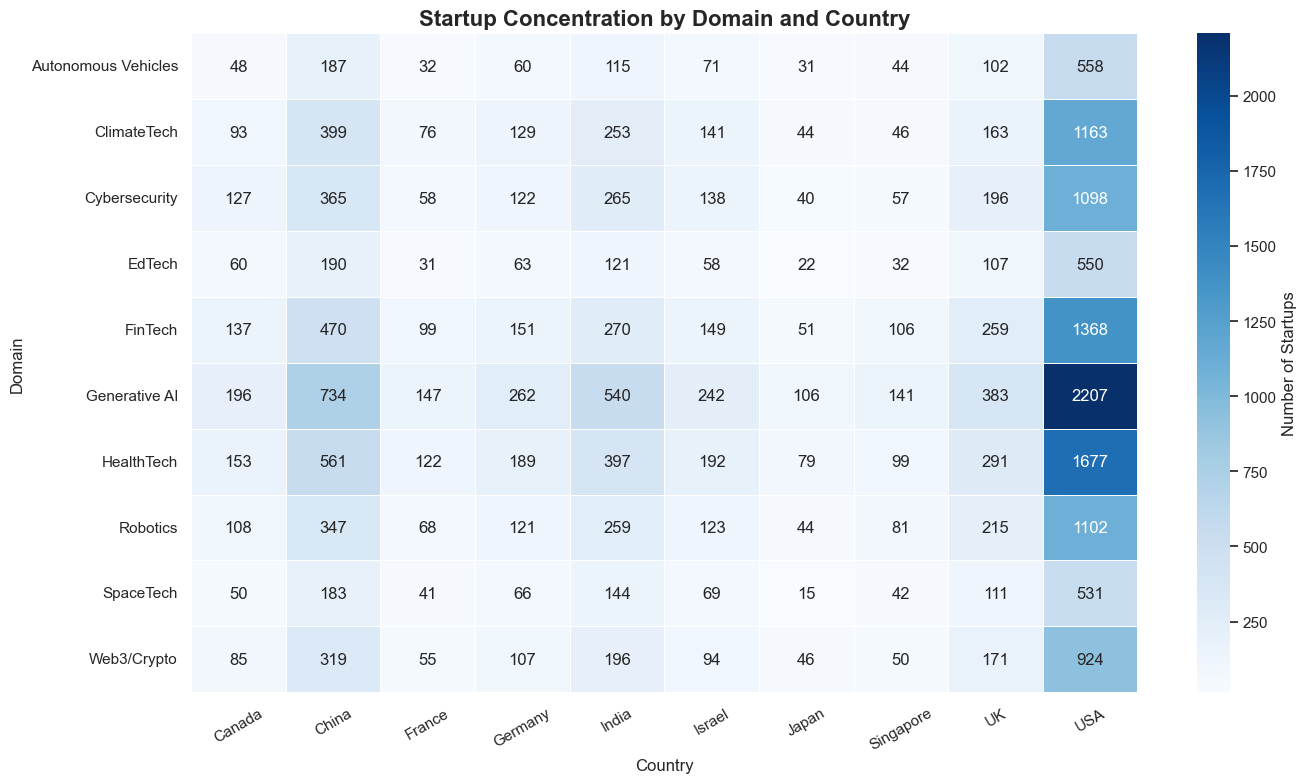

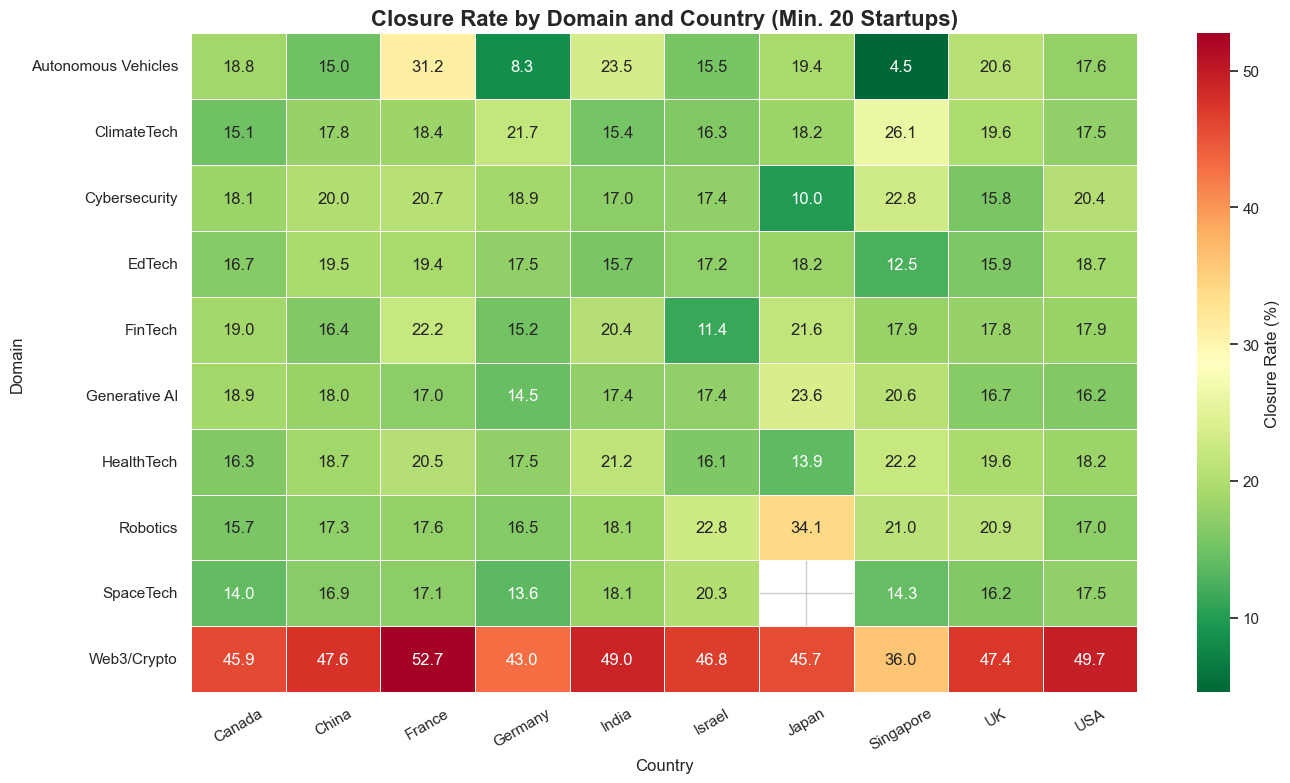

In [27]:
#Q6.Does that geographic positioning correspond with different survival?
# Create closure percentage

# HEATMAP 1: STARTUP COUNT
# Domain × Country → Number of Startups
startup_count = pd.crosstab(df["Domain"],df["Country"])

plt.figure(figsize=(14, 8))
sns.heatmap(startup_count,annot=True,fmt="d",cmap="Blues",linewidths=0.5,cbar_kws={"label": "Number of Startups"})
plt.title("Startup Concentration by Domain and Country",fontsize=16,fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Domain")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Count observations for each Domain × Country
cell_count = pd.crosstab(df["Domain"],df["Country"])
df["Closed"] = (df["Acquisition_Status"] == "Closed").astype(int)
closure_rate = (df.groupby(["Domain", "Country"])["Closed"].mean().mul(100).unstack())
# Keep only combinations with at least 20 startups
closure_rate_filtered = closure_rate.mask(cell_count < 20)
plt.figure(figsize=(14, 8))
sns.heatmap(closure_rate_filtered,annot=True,fmt=".1f",cmap="RdYlGn_r",linewidths=0.5,cbar_kws={"label": "Closure Rate (%)"})
plt.title("Closure Rate by Domain and Country (Min. 20 Startups)",fontsize=16,fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Domain")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight:  
The heatmap shows that most domains have moderate closure rates, generally around 13%-23%, with only a few higher-risk combinations. The biggest exception is Web3/Crypto, which has very high closure rates across almost every country, ranging from about 36% to 53%, making it a clear high-risk domain.  
There are also some country-specific differences—for example, Autonomous Vehicles in France (31.2%) and Robotics in Japan (34.1%) have relatively high closure rates. However, these differences are much smaller than the consistently high failure rate of Web3/Crypto.  

#### Important point about the blank cell  
The white cell for SpaceTech × Japan means that this combination did not meet the minimum 20-startup requirement

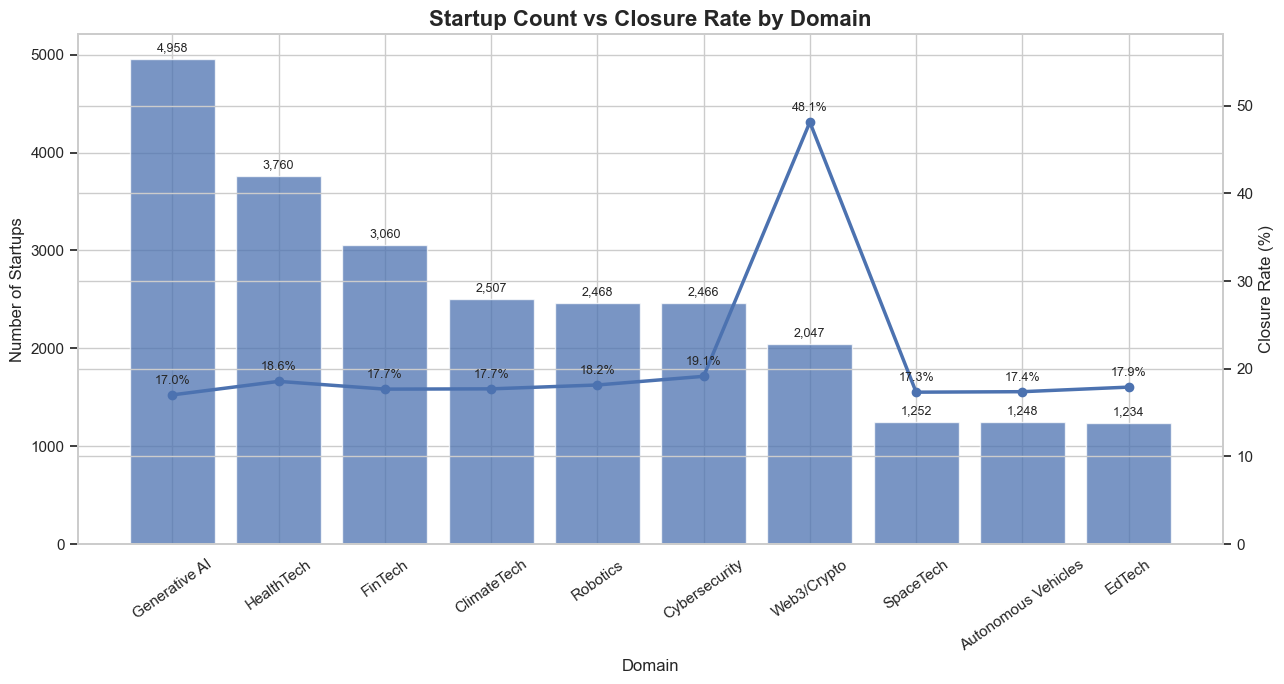

In [20]:
#Q7. Generative AI is the single largest category by far (nearly 5,000 companies) - does it also have the best survival rate,
#or is the space more crowded than it is successful?

# Calculate startup count and closure rate by domain
domain_stats = (df.groupby("Domain").agg(Startup_Count=("Company_ID", "count"),Closure_Rate=("Acquisition_Status",
lambda x: (x == "Closed").mean() * 100)).sort_values("Startup_Count", ascending=False))

# Create dual-axis chart
fig, ax1 = plt.subplots(figsize=(13, 7))

# Startup count bars
bars = ax1.bar(domain_stats.index,domain_stats["Startup_Count"],alpha=0.75,label="Startup Count")

ax1.set_xlabel("Domain")
ax1.set_ylabel("Number of Startups")
ax1.tick_params(axis="x", rotation=35)

# Second axis for closure rate
ax2 = ax1.twinx()

ax2.plot(domain_stats.index,domain_stats["Closure_Rate"],marker="o",linewidth=2.5,label="Closure Rate")

ax2.set_ylabel("Closure Rate (%)")
ax2.set_ylim(0, max(domain_stats["Closure_Rate"]) + 10)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 80,
        f"{int(height):,}",
        ha="center",
        fontsize=9
    )

# Add closure-rate labels
for i, rate in enumerate(domain_stats["Closure_Rate"]):
    ax2.annotate(f"{rate:.1f}%",(i, rate),xytext=(0, 8),textcoords="offset points",ha="center",fontsize=9)

plt.title("Startup Count vs Closure Rate by Domain",fontsize=16,fontweight="bold")

plt.tight_layout()
plt.show()

### Insight:
Generative AI is clearly the largest domain with 4,958 startups but its closure rate is only 17.0%. This is not the highest survival rate although it performs better than most major domains.  
The major exception is Web3/Crypto which has a much higher closure rate of 48.1% showing considerably greater risk despite having only 2,047 startups. Other large domains such as HealthTech FinTech and Robotics have closure rates around 18% while Cybersecurity is slightly higher at 19.1%.  


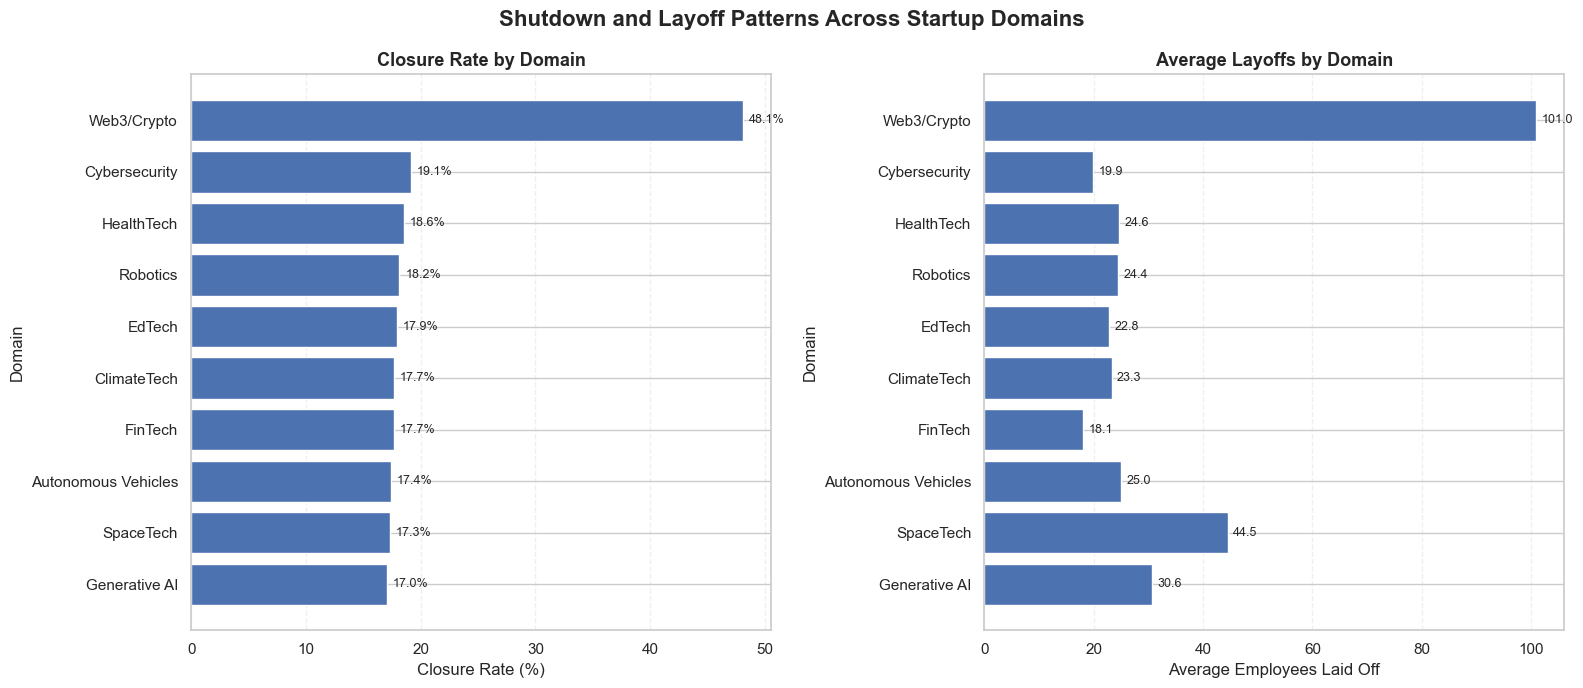

In [21]:
#Q8. Web3/Crypto stands out sharply from every other domain on failure metrics - what does its shutdown and layoff pattern actually 
#look like next to the rest of the market?
# Calculate failure metrics by domain
domain_failure = (df.groupby("Domain").agg(Closure_Rate=("Acquisition_Status",lambda x: (x == "Closed").mean() * 100),
Avg_Layoffs=("Layoffs_2024_2025", "mean")).sort_values("Closure_Rate", ascending=False))
# Create horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Closure Rate
axes[0].barh(domain_failure.index,domain_failure["Closure_Rate"])
axes[0].invert_yaxis()

for i, value in enumerate(domain_failure["Closure_Rate"]):
    axes[0].text(value + 0.5,i,f"{value:.1f}%",va="center",fontsize=9)

axes[0].set_title("Closure Rate by Domain",fontsize=13,fontweight="bold")
axes[0].set_xlabel("Closure Rate (%)")
axes[0].set_ylabel("Domain")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)


# 2. Average Layoffs
axes[1].barh(domain_failure.index,domain_failure["Avg_Layoffs"])
axes[1].invert_yaxis()

for i, value in enumerate(domain_failure["Avg_Layoffs"]):
    axes[1].text(value + 1, i,f"{value:.1f}",va="center",fontsize=9)

axes[1].set_title("Average Layoffs by Domain",fontsize=13,fontweight="bold")
axes[1].set_xlabel("Average Employees Laid Off")
axes[1].set_ylabel("Domain")
axes[1].grid(axis="x", linestyle="--", alpha=0.3)

plt.suptitle("Shutdown and Layoff Patterns Across Startup Domains",fontsize=16,fontweight="bold")

plt.tight_layout()
plt.show()

### Insight:  
Web3/Crypto is a clear outlier in both failure metrics. Its closure rate is approximately 48.1% far above the other domains where closure rates remain around 17–19%. This means Web3/Crypto startups are much more likely to shut down.  
The layoff pattern is also extreme: Web3/Crypto averages about 101 layoffs per startup while most other domains average roughly 18–45 layoffs. Generative AI has a relatively high average of about 31 layoffs but its closure rate remains much lower at around 17%.  

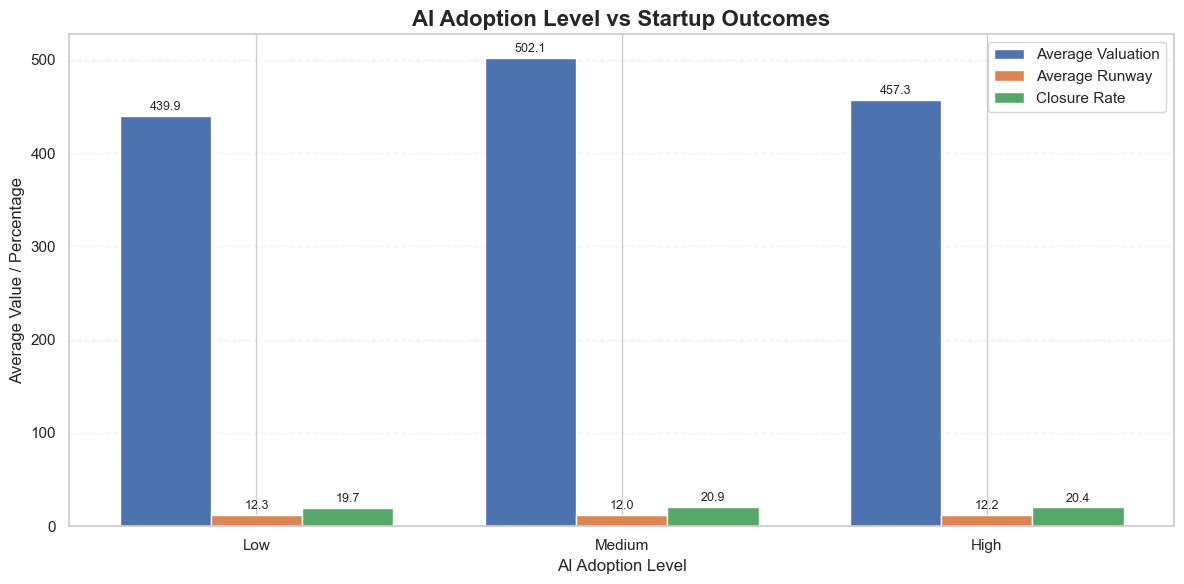

In [23]:
#Q9. Does a "High" AI_Adoption_Level actually translate into better valuation, longer runway or fewer shutdowns 
#or does adoption level barely move the needle on outcomes?
# Keep only valid AI adoption levels
ai_order = ["Low", "Medium", "High"]
data = df[df["AI_Adoption_Level"].isin(ai_order)]

# Calculate average outcomes
stats = (data.groupby("AI_Adoption_Level").agg(Avg_Valuation=("Valuation_USD_Millions", "mean"),Avg_Runway=("Runway_Months_2024", "mean"),
Closure_Rate=("Acquisition_Status",lambda x: (x == "Closed").mean() * 100)).reindex(ai_order))
# Create positions
x = np.arange(len(ai_order))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))

# Grouped bars
bars1 = ax.bar(x - width,stats["Avg_Valuation"],width,label="Average Valuation")

bars2 = ax.bar(x,stats["Avg_Runway"],width,label="Average Runway")

bars3 = ax.bar(x + width,stats["Closure_Rate"],width,label="Closure Rate")

# Labels
ax.set_title("AI Adoption Level vs Startup Outcomes",fontsize=16,fontweight="bold")
ax.set_xlabel("AI Adoption Level")
ax.set_ylabel("Average Value / Percentage")
ax.set_xticks(x)
ax.set_xticklabels(ai_order)

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}",
            (bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Insight

The graph shows that AI adoption level has very little effect on these outcomes. Average valuation is about 440M for Low, 502M for Medium and $457M for High while average runway remains almost unchanged at around 12 months across all three levels.

Closure rates are also very similar: approximately 19.7% (Low), 20.9% (Medium), and 20.4% (High). Therefore High AI adoption does not clearly provide better valuation, longer runway or fewer shutdowns in this dataset.

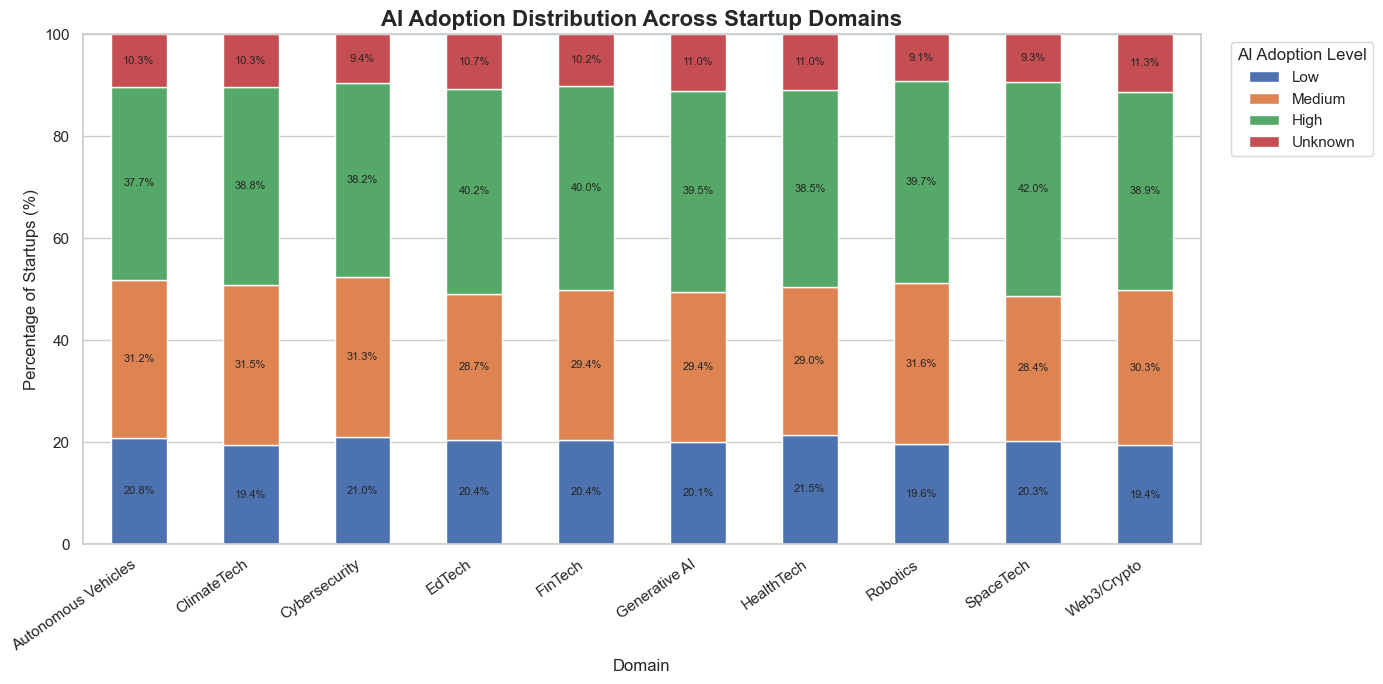

In [24]:
#Q10. Is AI adoption spread evenly across domains, or is it just a byproduct of what business you're 
#in (eg, a Generative AI company is "High" almost by definition)?
# Replace missing AI adoption values with "Unknown"
df["AI_Adoption_Level"] = df["AI_Adoption_Level"].fillna("Unknown")
# Calculate percentage distribution within each domain
ai_domain_pct = (pd.crosstab(df["Domain"],df["AI_Adoption_Level"],normalize="index") * 100)
# Keep a consistent order
ai_domain_pct = ai_domain_pct.reindex(columns=["Low", "Medium", "High", "Unknown"],fill_value=0)
# Plot 100% stacked bar chart
ax = ai_domain_pct.plot(kind="bar",stacked=True,figsize=(14, 7))
plt.title("AI Adoption Distribution Across Startup Domains",fontsize=16,fontweight="bold")
plt.xlabel("Domain")
plt.ylabel("Percentage of Startups (%)")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 100)
plt.legend(title="AI Adoption Level",bbox_to_anchor=(1.02, 1),loc="upper left")
# Add percentage labels
for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 5 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Insight

AI adoption is fairly evenly distributed across most domains, but High adoption is consistently the largest category. It ranges from about 37.7% in Autonomous Vehicles to 42.0% in SpaceTech. Generative AI itself has 39.5% High adoption which is very similar to most other domains.  

The Low and Medium categories also remain fairly consistent while the Unknown portion is around 9–11% across domains. Therefore AI adoption does not appear to be simply a byproduct of being a Generative AI company.

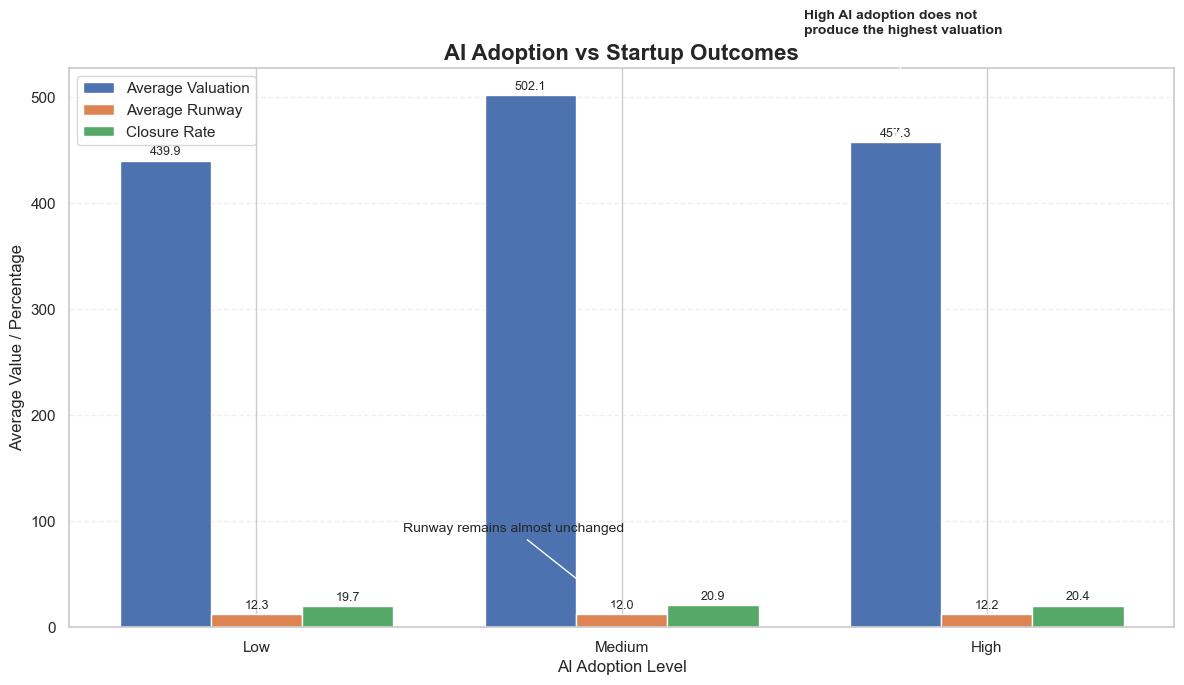

In [25]:
#Q11 If AI adoption turns out to have little to no relationship with survival or valuation in this data, what does that say about how the 
#market talks about "AI-native" startups versus how they actually perform?
# AI adoption order
ai_order = ["Low", "Medium", "High"]

# Calculate outcomes
stats = (df.groupby("AI_Adoption_Level").agg(Avg_Valuation=("Valuation_USD_Millions", "mean"),Avg_Runway=("Runway_Months_2024", "mean"),
Closure_Rate=("Acquisition_Status",lambda x: (x == "Closed").mean() * 100)).reindex(ai_order))
# X positions
x = np.arange(len(ai_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

# Bars
bars1 = ax.bar(x - width,stats["Avg_Valuation"],width,label="Average Valuation")
bars2 = ax.bar(x,stats["Avg_Runway"],width,label="Average Runway")

bars3 = ax.bar(x + width,stats["Closure_Rate"],width,label="Closure Rate")

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

# Highlight the important comparison
ax.annotate("High AI adoption does not\nproduce the highest valuation",xy=(2 - width, stats.loc["High", "Avg_Valuation"]),xytext=(1.5, 560),
arrowprops=dict(arrowstyle="->"),fontsize=10,fontweight="bold")

ax.annotate("Runway remains almost unchanged",xy=(1, stats.loc["Medium", "Avg_Runway"]),xytext=(0.4, 90),arrowprops=dict(arrowstyle="->"),fontsize=10)
ax.set_title("AI Adoption vs Startup Outcomes",fontsize=16,fontweight="bold")
ax.set_xlabel("AI Adoption Level")
ax.set_ylabel("Average Value / Percentage")
ax.set_xticks(x)
ax.set_xticklabels(ai_order)

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Insight

The annotated Q9 chart suggests that the market’s “AI-native” narrative is stronger than the performance difference shown in this dataset. High AI adoption does not produce the highest valuation: Medium adoption leads at 502.1M, compared with 457.3M for High and 439.9M for Low.

Runway is almost identical across all three groups (12.3, 12.0, and 12.2 months), while closure rates are also very close (19.7%, 20.9%, and 20.4%).

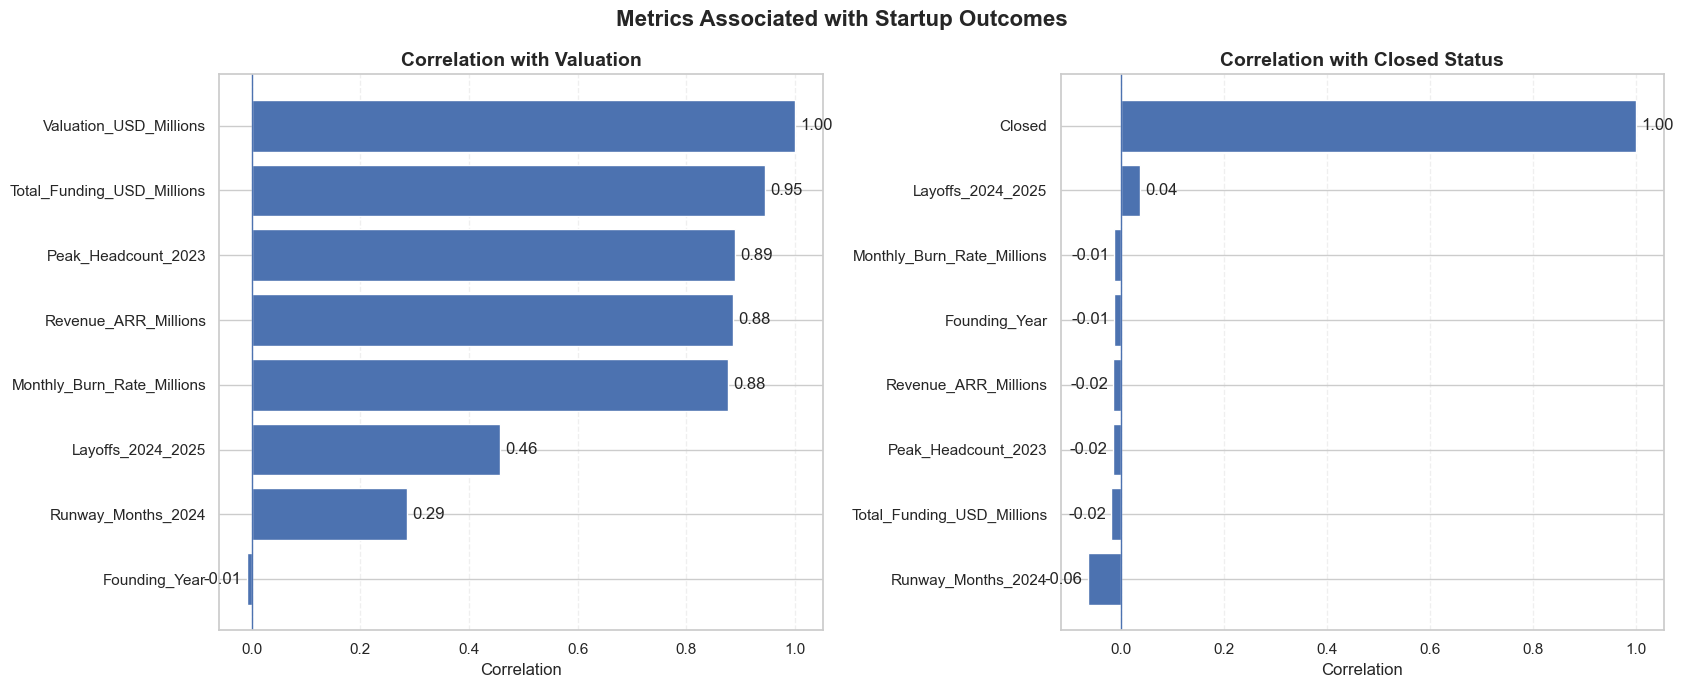

In [26]:
#Q12 If you were advising an investor using only this dataset, which single metric would you tell them to watch most closely before writing a check
#and why?
# Create binary target for closed status
df["Closed"] = (df["Acquisition_Status"] == "Closed").astype(int)

# Numerical features
features = ["Founding_Year","Total_Funding_USD_Millions","Revenue_ARR_Millions","Monthly_Burn_Rate_Millions","Runway_Months_2024","Peak_Headcount_2023","Layoffs_2024_2025"]

# Correlation with Valuation
valuation_corr = (df[features + ["Valuation_USD_Millions"]].corr()["Valuation_USD_Millions"].sort_values())
# Correlation with Closed
closed_corr = (df[features + ["Closed"]].corr()["Closed"].sort_values())
# Create plots
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
# Valuation correlation
axes[0].barh(valuation_corr.index,valuation_corr.values)
axes[0].axvline(0, linewidth=1)

for i, value in enumerate(valuation_corr.values):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

axes[0].set_title(
    "Correlation with Valuation",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_xlabel("Correlation")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)

# Closed correlation
axes[1].barh(closed_corr.index,closed_corr.values)
axes[1].axvline(0, linewidth=1)

for i, value in enumerate(closed_corr.values):
    axes[1].text(
        value + (0.01 if value >= 0 else -0.01),
        i,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

axes[1].set_title("Correlation with Closed Status",fontsize=14,fontweight="bold")
axes[1].set_xlabel("Correlation")
axes[1].grid(axis="x", linestyle="--", alpha=0.3)

plt.suptitle("Metrics Associated with Startup Outcomes",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()



### Insight
The strongest relationship with valuation is Total Funding with a very high correlation of approximately 0.95. Revenue headcount and burn rate also show strong positive relationships with valuation.  

However when looking at shutdown risk, the correlations are very weak. Runway has the strongest relationship with closure at about −0.06, meaning longer runway is associated with slightly lower closure risk, but the relationship is still very weak.  

### Conclusion
Total Funding is the strongest numerical indicator of valuation in this dataset, but no single numerical metric is a strong standalone predictor of startup survival.

### Executive Summary  
This EDA analyzed 25,000 tech startups across 10 domains, covering funding, valuation, burn rate, runway, geography, investors, AI adoption, and startup survival.  

The analysis shows that funding, valuation, burn rate, and company size increase as startups move to later funding stages. Runway also improves from about 5 months at Seed to nearly 24 months at Post-IPO. Tier 1 investors are linked with higher valuations, but the other investor tiers are much closer to each other.  

For survival, financial size alone does not strongly explain whether a startup closes. The biggest difference comes from the business domain. Web3/Crypto has a much higher closure rate than other domains, while most other sectors have fairly similar closure rates.  

The analysis also shows that AI adoption does not have a strong relationship with valuation, runway, or survival. High AI adoption does not automatically mean better performance, and AI adoption is spread across most technology domains.  

### Conclusion  

The main lesson is that growth and survival are different things. More funding can create bigger companies, higher valuations, and higher spending, but it does not guarantee survival. In this dataset, the business domain appears more important for survival than financial size or AI adoption. For an investor, the key question should therefore be not only “How much has the startup raised?” but also “What market is the startup competing in, and how sustainable is that business?”